# Spiral Disk Prior Visualization

Compare `DiskPrior` and `SpiralDiskPrior` to see how spiral arm overdensity
modulates the distance prior along different sightlines.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from candel.model.mwcepheids import DiskPrior, get_drimmel_arm_traces

In [5]:
# Parameters
R_sun = 8.122
R_d = 2.5
z_d = 0.1
d_min, d_max = 0.1, 8.0
amplitude = 2
arm_width = 0.3  # kpc

# Load arm traces
arm_xgc, arm_ygc = get_drimmel_arm_traces(R_sun=R_sun, use_extrapolated=True)
print(f"Arm trace points: {len(arm_xgc)}")

2026-02-11 13:40:07 Loaded 4 Drimmel arm traces (404 points, extrapolated=True)
Arm trace points: 404


## 1. Distance prior p(d) along representative sightlines

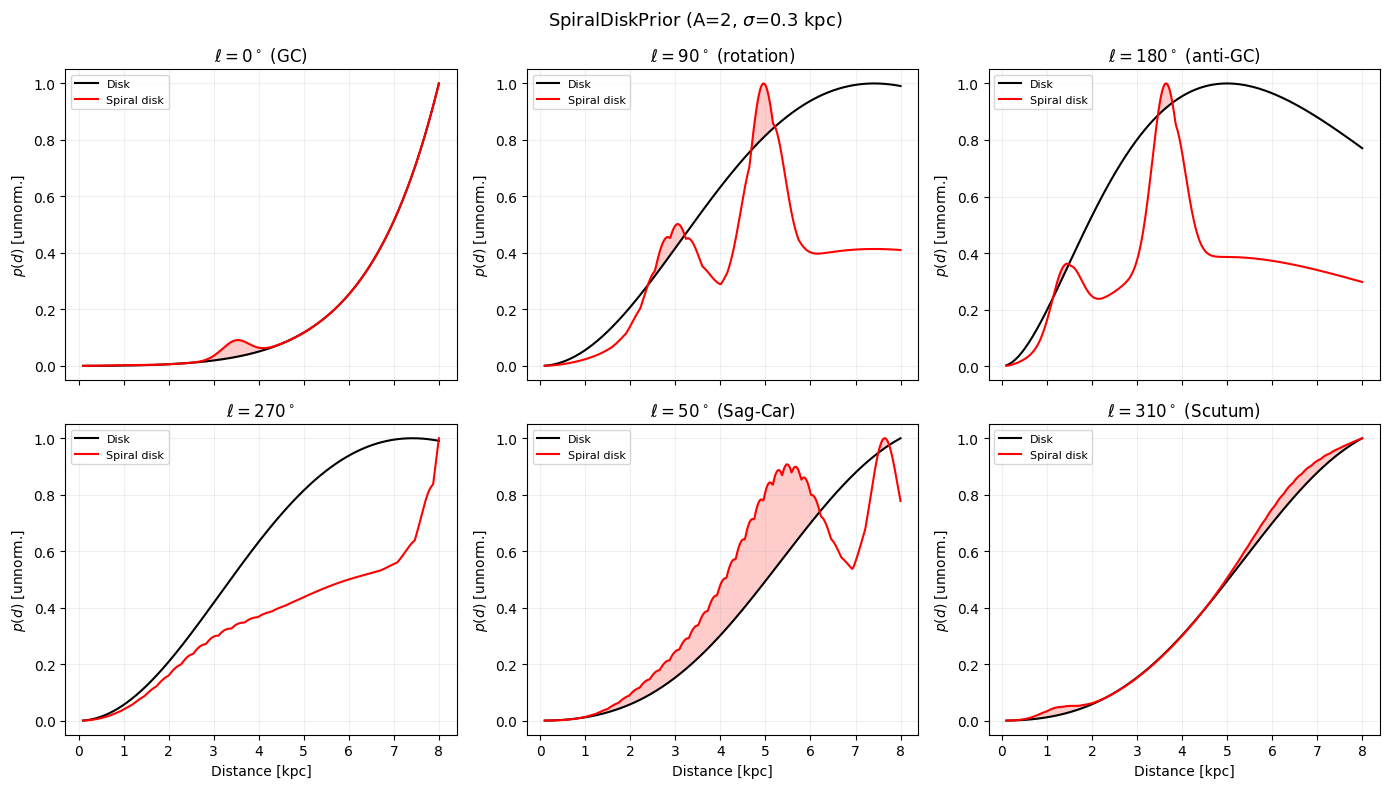

In [6]:
d_grid = jnp.linspace(d_min, d_max, 500)

# Sightlines: toward GC, toward anti-centre, along arms
sightlines = [
    (0, 0, "$\\ell=0^\\circ$ (GC)"),
    (90, 0, "$\\ell=90^\\circ$ (rotation)"),
    (180, 0, "$\\ell=180^\\circ$ (anti-GC)"),
    (270, 0, "$\\ell=270^\\circ$"),
    (50, 0, "$\\ell=50^\\circ$ (Sag-Car)"),
    (310, 0, "$\\ell=310^\\circ$ (Scutum)"),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True)
axes = axes.ravel()

for ax, (ell, b, label) in zip(axes, sightlines):
    # DiskPrior
    disk = DiskPrior(jnp.array([ell]), jnp.array([b]),
                     d_min, d_max, R_d=R_d, z_d=z_d, R_sun=R_sun)
    log_p_disk = disk._unnorm_log_prob(d_grid, grid_mode=True).squeeze(0)
    p_disk = jnp.exp(log_p_disk - jnp.max(log_p_disk))

    # SpiralDiskPrior
    spiral = SpiralDiskPrior(
        jnp.array([ell]), jnp.array([b]),
        d_min, d_max,
        arm_xgc=arm_xgc, arm_ygc=arm_ygc,
        amplitude=amplitude, arm_width=arm_width,
        R_d=R_d, z_d=z_d, R_sun=R_sun)
    log_p_spiral = spiral._unnorm_log_prob(d_grid, grid_mode=True).squeeze(0)
    p_spiral = jnp.exp(log_p_spiral - jnp.max(log_p_spiral))

    ax.plot(d_grid, p_disk, 'k-', lw=1.5, label='Disk')
    ax.plot(d_grid, p_spiral, 'r-', lw=1.5, label='Spiral disk')
    ax.fill_between(np.asarray(d_grid),
                    np.asarray(p_disk), np.asarray(p_spiral),
                    where=np.asarray(p_spiral > p_disk),
                    alpha=0.2, color='red')
    ax.set_title(label)
    ax.set_ylabel('$p(d)$ [unnorm.]')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

for ax in axes[-3:]:
    ax.set_xlabel('Distance [kpc]')

fig.suptitle(f'SpiralDiskPrior (A={amplitude}, $\\sigma$={arm_width} kpc)', fontsize=13)
plt.tight_layout()
plt.show()

## 2. Face-on density map (Galactic plane)

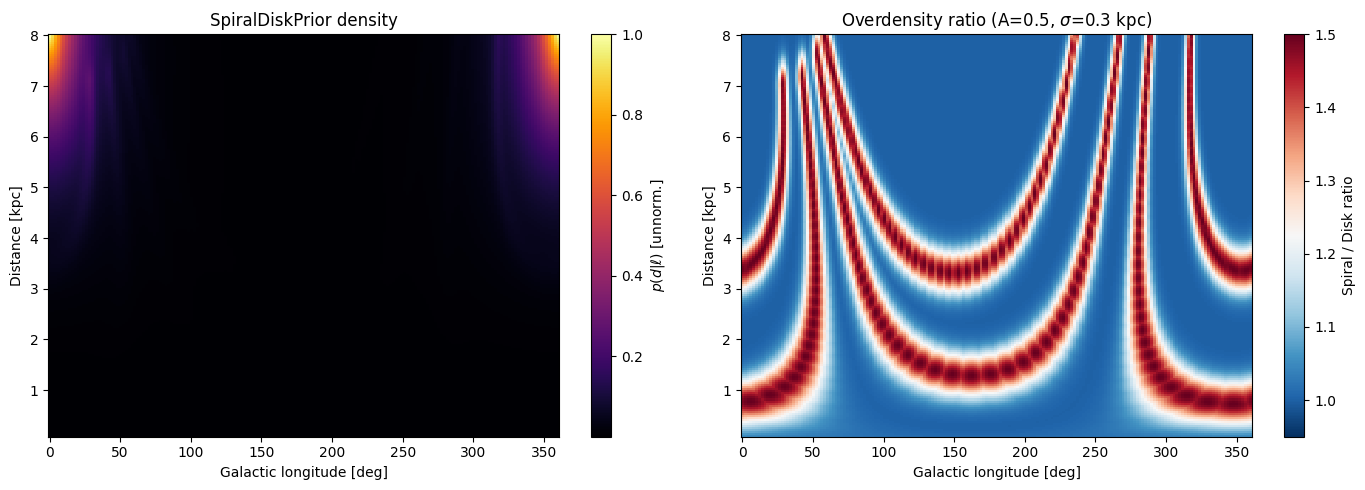

In [4]:
# Build a grid in (ell, d) and evaluate both priors
n_ell, n_d = 180, 200
ell_arr = np.linspace(0, 360, n_ell)
d_arr = jnp.linspace(d_min, d_max, n_d)

# DiskPrior on the grid
disk_all = DiskPrior(jnp.array(ell_arr), jnp.zeros(n_ell),
                     d_min, d_max, R_d=R_d, z_d=z_d, R_sun=R_sun)
log_p_disk_grid = disk_all._unnorm_log_prob(d_arr, grid_mode=True)

# SpiralDiskPrior on the grid
spiral_all = SpiralDiskPrior(
    jnp.array(ell_arr), jnp.zeros(n_ell),
    d_min, d_max,
    arm_xgc=arm_xgc, arm_ygc=arm_ygc,
    amplitude=amplitude, arm_width=arm_width,
    R_d=R_d, z_d=z_d, R_sun=R_sun)
log_p_spiral_grid = spiral_all._unnorm_log_prob(d_arr, grid_mode=True)

# Ratio: spiral / disk
ratio = np.exp(np.asarray(log_p_spiral_grid - log_p_disk_grid))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Spiral prior density (unnormalized)
ax = axes[0]
log_p_np = np.asarray(log_p_spiral_grid)
p_np = np.exp(log_p_np - np.max(log_p_np))
im = ax.pcolormesh(ell_arr, np.asarray(d_arr), p_np.T, cmap='inferno')
plt.colorbar(im, ax=ax, label='$p(d | \\ell)$ [unnorm.]')
ax.set_xlabel('Galactic longitude [deg]')
ax.set_ylabel('Distance [kpc]')
ax.set_title('SpiralDiskPrior density')

# Ratio
ax = axes[1]
im = ax.pcolormesh(ell_arr, np.asarray(d_arr), ratio.T, cmap='RdBu_r',
                   vmin=0.95, vmax=1.0 + amplitude)
plt.colorbar(im, ax=ax, label='Spiral / Disk ratio')
ax.set_xlabel('Galactic longitude [deg]')
ax.set_ylabel('Distance [kpc]')
ax.set_title(f'Overdensity ratio (A={amplitude}, $\\sigma$={arm_width} kpc)')

plt.tight_layout()
plt.show()

## 3. Face-on Cartesian density map with arm traces

In [ ]:
from SpiralMap.models_ import spiral_drimmel_cepheids

# Evaluate the spiral prior on a Cartesian grid in the Galactic plane.
# We compute unnormalized density directly (avoid constructing a
# SpiralDiskPrior with 90k stars, which would OOM in _compute_log_norm).
n_xy = 300
xy_range = 12
x_gc_arr = np.linspace(-xy_range, xy_range, n_xy)
y_gc_arr = np.linspace(-xy_range, xy_range, n_xy)
x_gc_mesh, y_gc_mesh = np.meshgrid(x_gc_arr, y_gc_arr)

# Galactocentric radius and height (b=0 plane)
R_GC = np.sqrt(x_gc_mesh**2 + y_gc_mesh**2)

# Heliocentric distance
x_hc = x_gc_mesh + R_sun
y_hc = y_gc_mesh
d_mesh = np.sqrt(x_hc**2 + y_hc**2)

# Smooth disk: d^2 * exp(-R_GC/R_d)  (z=0 so no z_d term)
log_p_disk_map = 2.0 * np.log(np.clip(d_mesh, 1e-10, None)) - R_GC / R_d

# Spiral arm factor
arm_xgc_np = np.asarray(arm_xgc)
arm_ygc_np = np.asarray(arm_ygc)
dx = x_gc_mesh[..., None] - arm_xgc_np[None, None, :]
dy = y_gc_mesh[..., None] - arm_ygc_np[None, None, :]
min_dist_sq = np.min(dx**2 + dy**2, axis=-1)
spiral_factor = np.log1p(amplitude * np.exp(-min_dist_sq / (2 * arm_width**2)))

log_p_spiral_map = log_p_disk_map + spiral_factor
print(f"Cartesian grid: {n_xy}x{n_xy}, spiral factor range: [{spiral_factor.min():.3f}, {spiral_factor.max():.3f}]")

In [ ]:
# Initialize Drimmel model for plotting arm traces
drimmel = spiral_drimmel_cepheids()
drimmel.xsun = -R_sun
drimmel.getarmlist()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Smooth disk
ax = axes[0]
p_disk = np.exp(log_p_disk_map - np.nanmax(log_p_disk_map))
im = ax.pcolormesh(x_gc_arr, y_gc_arr, p_disk, cmap='inferno')
plt.colorbar(im, ax=ax, label='Density [unnorm.]')
ax.set_title('DiskPrior')

# Spiral disk
ax = axes[1]
p_spiral = np.exp(log_p_spiral_map - np.nanmax(log_p_spiral_map))
im = ax.pcolormesh(x_gc_arr, y_gc_arr, p_spiral, cmap='inferno')
plt.colorbar(im, ax=ax, label='Density [unnorm.]')
ax.set_title('SpiralDiskPrior')

# Ratio
ax = axes[2]
ratio_map = np.exp(log_p_spiral_map - log_p_disk_map)
im = ax.pcolormesh(x_gc_arr, y_gc_arr, ratio_map, cmap='RdBu_r',
                   vmin=0.95, vmax=1.0 + amplitude)
plt.colorbar(im, ax=ax, label='Spiral / Disk')
ax.set_title('Overdensity ratio')

# Annotate all panels
for ax in axes:
    for arm in drimmel.arms:
        drimmel.output_(arm)
        ax.plot(drimmel.dout['xgc_ex'], drimmel.dout['ygc_ex'],
                color=drimmel.armcolour[arm], lw=1, ls='--', alpha=0.7)
    ax.plot(0, 0, 'w*', ms=10, zorder=10)
    ax.plot(-R_sun, 0, 'o', color='orange', ms=7, zorder=10)
    ax.set_xlabel('$X_{GC}$ [kpc]')
    ax.set_ylabel('$Y_{GC}$ [kpc]')
    ax.set_aspect('equal')
    ax.set_xlim(-xy_range, xy_range)
    ax.set_ylim(-xy_range, xy_range)

fig.suptitle(f'Face-on density (A={amplitude}, $\\sigma$={arm_width} kpc)', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Effect of amplitude and width

In [ ]:
# Show p(d) for ell=50 deg (through Sag-Car arm) varying A and sigma
ell_test = 50.0
b_test = 0.0

amplitudes = [0.0, 0.3, 0.5, 1.0, 2.0]
widths = [0.15, 0.3, 0.5, 0.8]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Vary amplitude at fixed width
ax = axes[0]
for A in amplitudes:
    if A == 0:
        prior = DiskPrior(jnp.array([ell_test]), jnp.array([b_test]),
                          d_min, d_max, R_d=R_d, z_d=z_d, R_sun=R_sun)
    else:
        prior = SpiralDiskPrior(
            jnp.array([ell_test]), jnp.array([b_test]),
            d_min, d_max,
            arm_xgc=arm_xgc, arm_ygc=arm_ygc,
            amplitude=A, arm_width=arm_width,
            R_d=R_d, z_d=z_d, R_sun=R_sun)
    log_p = prior._unnorm_log_prob(d_grid, grid_mode=True).squeeze(0)
    p = jnp.exp(log_p - jnp.max(log_p))
    ax.plot(d_grid, p, lw=1.5, label=f'A = {A}')

ax.set_xlabel('Distance [kpc]')
ax.set_ylabel('$p(d)$ [unnorm.]')
ax.set_title(f'$\\ell={ell_test}^\\circ$ — varying amplitude ($\\sigma={arm_width}$ kpc)')
ax.legend(fontsize=9)
ax.grid(alpha=0.2)

# Vary width at fixed amplitude
ax = axes[1]
for w in widths:
    prior = SpiralDiskPrior(
        jnp.array([ell_test]), jnp.array([b_test]),
        d_min, d_max,
        arm_xgc=arm_xgc, arm_ygc=arm_ygc,
        amplitude=amplitude, arm_width=w,
        R_d=R_d, z_d=z_d, R_sun=R_sun)
    log_p = prior._unnorm_log_prob(d_grid, grid_mode=True).squeeze(0)
    p = jnp.exp(log_p - jnp.max(log_p))
    ax.plot(d_grid, p, lw=1.5, label=f'$\\sigma$ = {w} kpc')

ax.set_xlabel('Distance [kpc]')
ax.set_ylabel('$p(d)$ [unnorm.]')
ax.set_title(f'$\\ell={ell_test}^\\circ$ — varying width (A={amplitude})')
ax.legend(fontsize=9)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 5. Consistency check: amplitude=0 matches DiskPrior

In [ ]:
# Verify that SpiralDiskPrior(amplitude=0) == DiskPrior
ell_check = jnp.array([30.0, 90.0, 180.0, 270.0])
b_check = jnp.array([0.0, 5.0, -3.0, 2.0])
d_check = jnp.linspace(d_min, d_max, 100)

disk_check = DiskPrior(ell_check, b_check, d_min, d_max,
                       R_d=R_d, z_d=z_d, R_sun=R_sun)
spiral_check = SpiralDiskPrior(
    ell_check, b_check, d_min, d_max,
    arm_xgc=arm_xgc, arm_ygc=arm_ygc,
    amplitude=0.0, arm_width=arm_width,
    R_d=R_d, z_d=z_d, R_sun=R_sun)

log_p_d = disk_check._unnorm_log_prob(d_check, grid_mode=True)
log_p_s = spiral_check._unnorm_log_prob(d_check, grid_mode=True)

max_diff = float(jnp.max(jnp.abs(log_p_d - log_p_s)))
print(f"Max |log_p_disk - log_p_spiral(A=0)|: {max_diff:.2e}")
assert max_diff < 1e-10, f"Mismatch: {max_diff}"
print("PASSED: SpiralDiskPrior(amplitude=0) matches DiskPrior exactly.")